In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for cleaner charts
sns.set_theme(style="whitegrid")

# Load your cleaned dataset using your exact folder name (2_processed)
df = pd.read_csv(r'D:\e-commerce-data-analytics-project\1_Data\2_processed\ecommerce_cleaned.csv')

print("Cleaned data loaded for EDA! Shape:", df.shape)

# 1. Product Category Performance (Revenue & Volume)
print("\n--- Top Product Categories by Net Revenue ---")
category_perf = df.groupby('Product Category').agg(
    Total_Orders=('TID', 'count'),
    Total_Net_Revenue=('Net Amount', 'sum'),
    Avg_Order_Value=('Net Amount', 'mean')
).sort_values(by='Total_Net_Revenue', ascending=False)

display(category_perf)

# 2. Customer Segmentation: Repeat Buyers vs One-time Buyers
print("\n--- Customer Purchase Frequency Analysis ---")
customer_orders = df.groupby('CID').agg(
    Order_Count=('TID', 'count'),
    Total_Spend=('Net Amount', 'sum')
).reset_index()

repeat_buyers = customer_orders[customer_orders['Order_Count'] > 1]
print(f"Total Unique Customers: {customer_orders['CID'].nunique():,}")
print(f"Customers with 1 purchase: {len(customer_orders[customer_orders['Order_Count'] == 1]):,}")
print(f"Customers with 2+ purchases (Repeat): {len(repeat_buyers):,}")

Cleaned data loaded for EDA! Shape: (54387, 17)

--- Top Product Categories by Net Revenue ---


,Total_Orders,Total_Net_Revenue,Avg_Order_Value
Product Category,,,
Electronics,16362,4.750771e+07,2903.539470
Clothing,10833,3.123458e+07,2883.281110
Beauty and Health,8255,2.419339e+07,2930.756482
Sports & Fitness,5514,1.614434e+07,2927.882603
Home & Kitchen,5429,1.589920e+07,2928.569026
Books,2734,7.935474e+06,2902.514191
Other,2143,6.212374e+06,2898.914745
Pet Care,1605,4.638469e+06,2890.012148
Toys & Games,1512,4.479071e+06,2962.348456



--- Customer Purchase Frequency Analysis ---
Total Unique Customers: 28,921
Customers with 1 purchase: 13,062
Customers with 2+ purchases (Repeat): 15,859


In [5]:
# 3. Monthly Revenue Trends
print("\n--- Monthly Revenue Trends ---")
monthly_trend = df.groupby(['Year', 'Month', 'Month Name']).agg(
    Total_Orders=('TID', 'count'),
    Monthly_Net_Revenue=('Net Amount', 'sum')
).reset_index().sort_values(by=['Year', 'Month'])

display(monthly_trend.head(12))

# 4. Revenue by Customer Demographics (Gender & Age Group)
print("\n--- Revenue by Gender ---")
gender_rev = df.groupby('Gender').agg(
    Total_Orders=('TID', 'count'),
    Total_Net_Revenue=('Net Amount', 'sum'),
    Avg_Order_Value=('Net Amount', 'mean')
).sort_values(by='Total_Net_Revenue', ascending=False)
display(gender_rev)

print("\n--- Revenue by Age Group ---")
age_rev = df.groupby('Age Group').agg(
    Total_Orders=('TID', 'count'),
    Total_Net_Revenue=('Net Amount', 'sum'),
    Avg_Order_Value=('Net Amount', 'mean')
).sort_values(by='Total_Net_Revenue', ascending=False)
display(age_rev)


--- Monthly Revenue Trends ---


,Year,Month,Month Name,Total_Orders,Monthly_Net_Revenue
0,2019,9,September,349,9.253945e+05
1,2019,10,October,966,2.699066e+06
2,2019,11,November,848,2.714410e+06
3,2019,12,December,903,3.203997e+06
4,2020,1,January,908,2.100028e+06
5,2020,2,February,854,1.830274e+06
6,2020,3,March,962,2.416066e+06
7,2020,4,April,923,2.393578e+06
8,2020,5,May,923,2.411206e+06
9,2020,6,June,876,2.041764e+06



--- Revenue by Gender ---


,Total_Orders,Total_Net_Revenue,Avg_Order_Value
Gender,,,
Other,18266,5.358263e+07,2933.462969
Female,18228,5.273965e+07,2893.331935
Male,17893,5.192234e+07,2901.824015



--- Revenue by Age Group ---


,Total_Orders,Total_Net_Revenue,Avg_Order_Value
Age Group,,,
25-45,21789,6.395892e+07,2935.376385
18-25,16236,4.682572e+07,2884.067501
45-60,10977,3.169728e+07,2887.608780
under 18,2731,8.011076e+06,2933.385454
60 and above,2654,7.751633e+06,2920.735852


Generating: Clean Monthly Revenue Trend...
  -> Saved Clean Chart: D:\e-commerce-data-analytics-project\4_images\04_monthly_revenue_trend.png


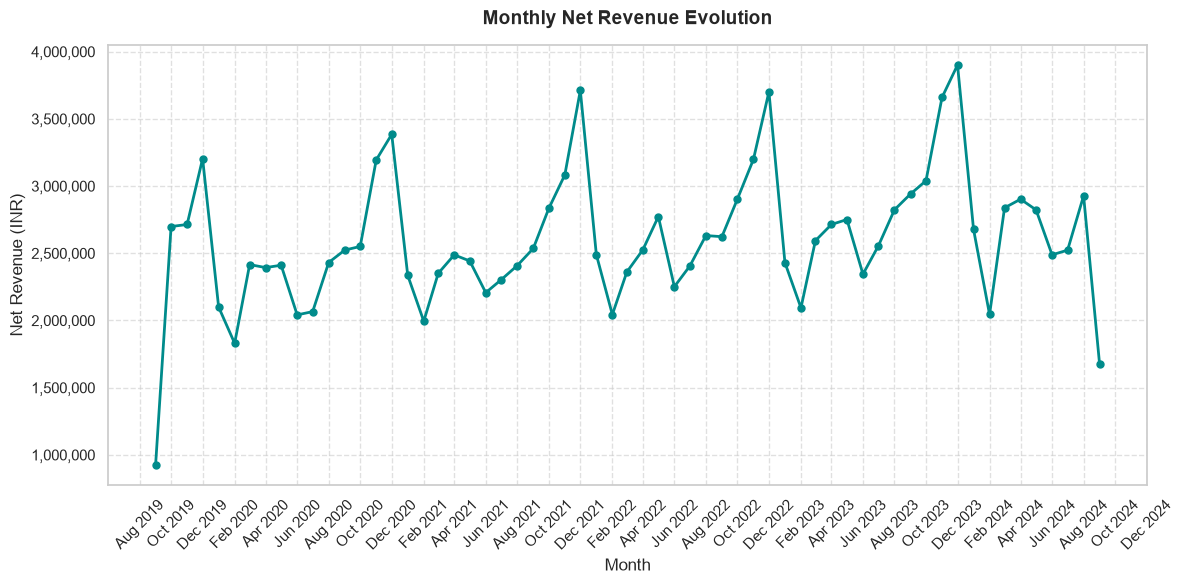

In [8]:
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Ensure 'Purchase Date' is datetime
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

print("Generating: Clean Monthly Revenue Trend...")
plt.figure(figsize=(12, 6), dpi=100)

# Group by year-month period for proper chronological sorting
monthly_trend = df.groupby(df['Purchase Date'].dt.to_period('M'))['Net Amount'].sum().reset_index()
monthly_trend['Purchase Date'] = monthly_trend['Purchase Date'].dt.to_timestamp()

# Plot line chart
plt.plot(monthly_trend['Purchase Date'], monthly_trend['Net Amount'], marker='o', color='darkcyan', linewidth=2, markersize=5)

plt.title('Monthly Net Revenue Evolution', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Net Revenue (INR)', fontsize=12)

# --- X-Axis Formatting to Prevent Overcrowding ---
# Format as Month & Year (e.g., Jan 2023)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
# Set interval to every 2 or 3 months so labels don't crash into each other
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: '{:,}'.format(int(x))))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Save the updated chart
monthly_path = os.path.join(VISUALS_DIR, '04_monthly_revenue_trend.png')
plt.savefig(monthly_path)
print(f"  -> Saved Clean Chart: {monthly_path}")
plt.show()

Generating: Customer Tier Distribution...
  -> Saved: D:\e-commerce-data-analytics-project\4_images\06_customer_tiers.png


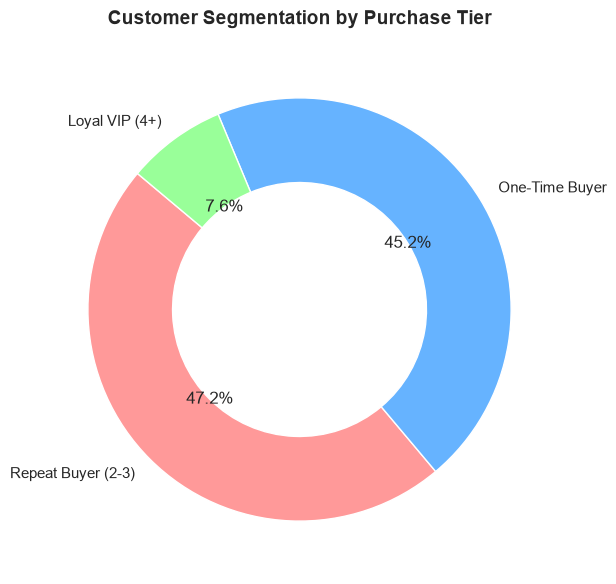


Generating: Top 5 Locations by Revenue...
  -> Saved: D:\e-commerce-data-analytics-project\4_images\07_top_locations.png


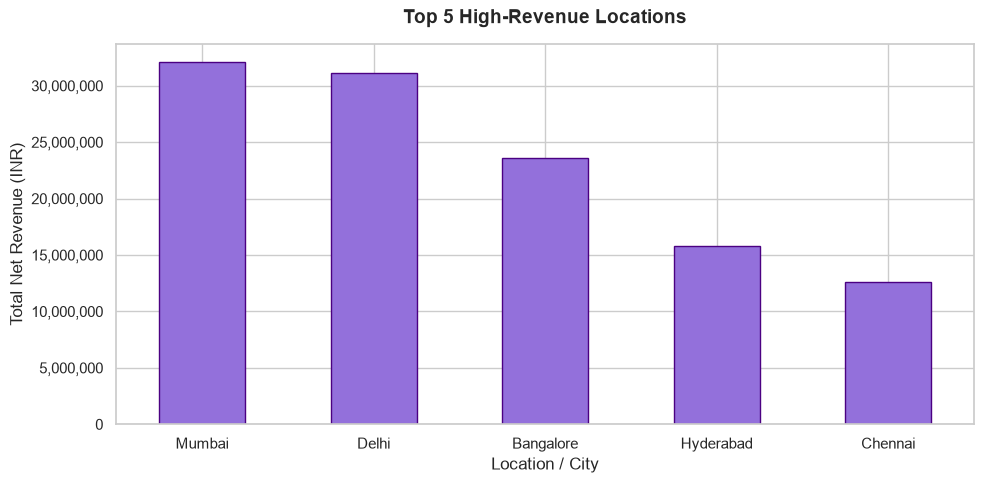


✅ Customer Tiers and Top Locations charts created and saved successfully!


In [9]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure visuals directory is ready
VISUALS_DIR = r'D:\e-commerce-data-analytics-project\4_images'
os.makedirs(VISUALS_DIR, exist_ok=True)

# --- Visualization 6: Customer Tier Distribution (Donut Chart) ---
print("Generating: Customer Tier Distribution...")

# Calculate customer order frequency to segment them
customer_orders = df.groupby('CID')['TID'].count().reset_index()
customer_orders.rename(columns={'TID': 'Total_Orders'}, inplace=True)

def get_tier(orders):
    if orders == 1:
        return 'One-Time Buyer'
    elif orders <= 3:
        return 'Repeat Buyer (2-3)'
    else:
        return 'Loyal VIP (4+)'

customer_orders['Customer_Tier'] = customer_orders['Total_Orders'].apply(get_tier)
tier_counts = customer_orders['Customer_Tier'].value_counts()

plt.figure(figsize=(8, 6), dpi=100)
colors = ['#ff9999', '#66b3ff', '#99ff99']
plt.pie(tier_counts, labels=tier_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, 
        wedgeprops=dict(width=0.4, edgecolor='w')) # width makes it a donut chart

plt.title('Customer Segmentation by Purchase Tier', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

tier_path = os.path.join(VISUALS_DIR, '06_customer_tiers.png')
plt.savefig(tier_path)
print(f"  -> Saved: {tier_path}")
plt.show()


# --- Visualization 7: Top 5 Locations by Net Revenue (Bar Chart) ---
print("\nGenerating: Top 5 Locations by Revenue...")
plt.figure(figsize=(10, 5), dpi=100)

location_rev = df.groupby('Location')['Net Amount'].sum().sort_values(ascending=False).head(5)

ax = location_rev.plot(kind='bar', color='mediumpurple', edgecolor='indigo')
plt.title('Top 5 High-Revenue Locations', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Location / City', fontsize=12)
plt.ylabel('Total Net Revenue (INR)', fontsize=12)
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: '{:,}'.format(int(x))))
plt.tight_layout()

loc_path = os.path.join(VISUALS_DIR, '07_top_locations.png')
plt.savefig(loc_path)
print(f"  -> Saved: {loc_path}")
plt.show()

print("\n✅ Customer Tiers and Top Locations charts created and saved successfully!")

Generating: 05_discount_impact.png...
Using discount column: 'Discount Availed'


<Figure size 900x500 with 0 Axes>

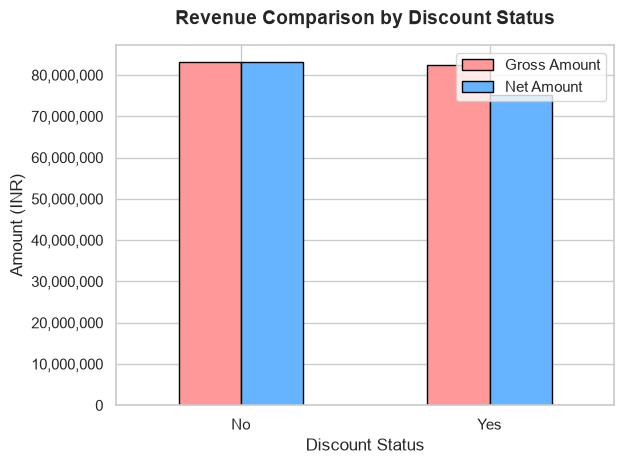

Generating: 06_aov_by_category.png...


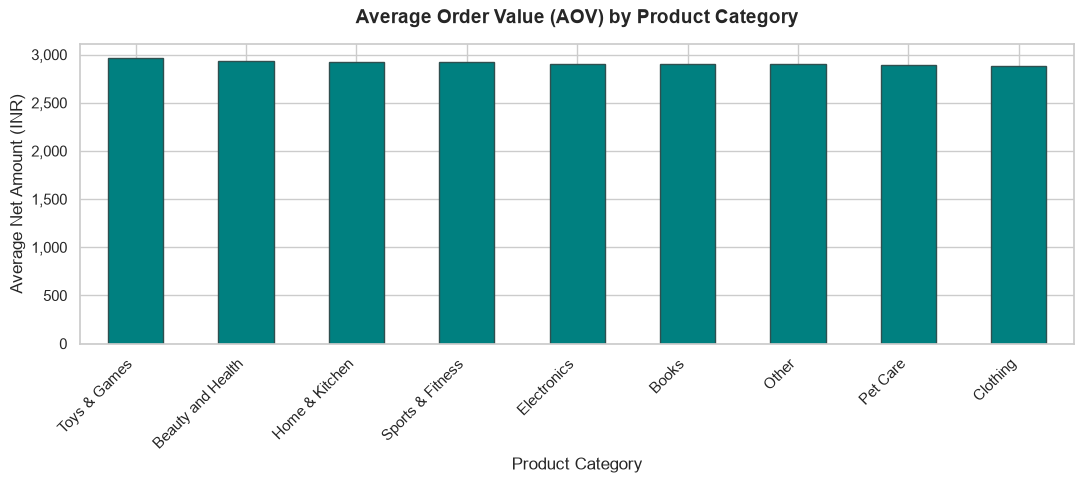


✅ Charts 05 and 06 successfully created and saved!


In [11]:
import os
import matplotlib.pyplot as plt
import pandas as pd

VISUALS_DIR = r'D:\e-commerce-data-analytics-project\4_images'
os.makedirs(VISUALS_DIR, exist_ok=True)

# --- Chart 5: Discount Impact Analysis ---
print("Generating: 05_discount_impact.png...")

# Automatically find the correct discount column name
discount_col = [col for col in df.columns if 'discount' in col.lower() and ('avail' in col.lower() or 'flag' in col.lower() or 'yes' in col.lower())]
if not discount_col:
    for name in ['Discount_Availed', 'Discount Availed', 'discount_availed']:
        if name in df.columns:
            discount_col = [name]
            break

disc_column_name = discount_col[0] if discount_col else 'Discount_Availed'
print(f"Using discount column: '{disc_column_name}'")

plt.figure(figsize=(9, 5), dpi=100)
discount_rev = df.groupby(disc_column_name)[['Gross Amount', 'Net Amount']].sum()

ax = discount_rev.plot(kind='bar', color=['#ff9999', '#66b3ff'], edgecolor='black')
plt.title('Revenue Comparison by Discount Status', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Discount Status', fontsize=12)
plt.ylabel('Amount (INR)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(['Gross Amount', 'Net Amount'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: '{:,}'.format(int(x))))
plt.tight_layout()
plt.savefig(os.path.join(VISUALS_DIR, '05_discount_impact.png'))
plt.show()

# --- Chart 6: Average Order Value by Product Category ---
print("Generating: 06_aov_by_category.png...")
plt.figure(figsize=(11, 5), dpi=100)
aov_cat = df.groupby('Product Category')['Net Amount'].mean().sort_values(ascending=False)

ax = aov_cat.plot(kind='bar', color='teal', edgecolor='darkslategray')
plt.title('Average Order Value (AOV) by Product Category', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Average Net Amount (INR)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: '{:,}'.format(int(x))))
plt.tight_layout()
plt.savefig(os.path.join(VISUALS_DIR, '06_aov_by_category.png'))
plt.show()

print("\n✅ Charts 05 and 06 successfully created and saved!")